<a id="section3"></a>

---

## §3 Part 1 — Ensemble learning for heart disease prediction


### 3.1 — Data Preparation

#### Task 1 — Load Cleveland data, column schema, outcome definition

**File:** `processed.cleveland.data`.

**Missingness:** Rows with placeholder `?` are dropped explicitly; retained sample size $n$ is reported for transparency

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RANDOM_STATE = 42

# Standard Cleveland attribute names
COLUMN_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num",
]
DATA_PATH = "processed.cleveland.data"

df_raw = pd.read_csv(DATA_PATH, names=COLUMN_NAMES, na_values="?")
missing_rows = int(df_raw.isna().any(axis=1).sum())
df = df_raw.dropna().copy().reset_index(drop=True)

df["target"] = (df["num"] > 0).astype(int)
feature_cols = [c for c in COLUMN_NAMES if c != "num"]
X = df[feature_cols]
y = df["target"]

print("Rows in file:", len(df_raw))
print("Rows with any missing marker (?):", missing_rows)
print("Complete-case rows retained:", len(df))
print("\nOriginal severity counts (num):")
display(df["num"].value_counts().sort_index().to_frame("count"))

print("\nBinary target:")
display(y.value_counts().rename(index={0: "no disease", 1: "disease"}).to_frame("count"))
print("\nPatient-level positive rate:", f"{y.mean():.4f}")

Rows in file: 303
Rows with any missing marker (?): 6
Complete-case rows retained: 297

Original severity counts (num):


,count
num,
0,160
1,54
2,35
3,35
4,13



Binary target:


,count
target,
no disease,160
disease,137



Patient-level positive rate: 0.4613


**Dataset description.**

- **(a)** There are **303** records in the raw file; after removing incomplete rows, **297** patients remain. Each row is **one individual** with stress/lab/ECG attributes and an angiographic disease label.
- **(b)** **13** predictors. **Continuous:** `age`, `trestbps`, `chol`, `thalach`, `oldpeak`. **Categorical (integer-coded):** `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`.
- **(c)** `num` originally encodes severity 0–4; we **binarise** to **0 = absent** and **1 = present** for all assignments.

#### Task 2 — Stratified train/test partition (80% / 20%)

`train_test_split(..., stratify=y, random_state=RANDOM_STATE)` guarantees both partitions mirror the **class ratio** of the complete-case frame.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

print(f"Train n = {len(X_train)} | Test n = {len(X_test)}")
props = pd.DataFrame({
    "full": y.value_counts(normalize=True).sort_index(),
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
})
props.index = props.index.map({0: "no disease (0)", 1: "disease (1)"})
props.index.name = None
display(props.round(4))

Train n = 237 | Test n = 60


,full,train,test
no disease (0),0.5387,0.5401,0.5333
disease (1),0.4613,0.4599,0.4667


### 3.2 Task 3&4 — Supervised models

**Baseline:** depth-unlimited `DecisionTreeClassifier` (single tree, high variance).

**Ensembles:** `RandomForestClassifier` (**500** trees) — bagging + feature subsampling; `AdaBoostClassifier` (**500** estimators) — sequential reweighting of errors.

**Evaluation:** accuracy + `classification_report` on the **hold-out** test fold.

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
print(f"Decision tree — test accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=["no disease (0)", "disease (1)"]))

Decision tree — test accuracy: 0.7000
                precision    recall  f1-score   support

no disease (0)       0.71      0.75      0.73        32
   disease (1)       0.69      0.64      0.67        28

      accuracy                           0.70        60
     macro avg       0.70      0.70      0.70        60
  weighted avg       0.70      0.70      0.70        60



In [4]:
rf_clf = RandomForestClassifier(
    n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1,
).fit(X_train, y_train)
ada_clf = AdaBoostClassifier(
    n_estimators=500, random_state=RANDOM_STATE,
).fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_pred_ada = ada_clf.predict(X_test)

for label, preds in [
    ("Random Forest", y_pred_rf),
    ("AdaBoost", y_pred_ada),
]:
    print(f"{label} — test accuracy: {accuracy_score(y_test, preds):.4f}")

print("\nRandom Forest:")
print(classification_report(y_test, y_pred_rf, target_names=["no disease (0)", "disease (1)"]))
print("AdaBoost:")
print(classification_report(y_test, y_pred_ada, target_names=["no disease (0)", "disease (1)"]))

Random Forest — test accuracy: 0.8667
AdaBoost — test accuracy: 0.8500

Random Forest:
                precision    recall  f1-score   support

no disease (0)       0.85      0.91      0.88        32
   disease (1)       0.88      0.82      0.85        28

      accuracy                           0.87        60
     macro avg       0.87      0.86      0.87        60
  weighted avg       0.87      0.87      0.87        60

AdaBoost:
                precision    recall  f1-score   support

no disease (0)       0.87      0.84      0.86        32
   disease (1)       0.83      0.86      0.84        28

      accuracy                           0.85        60
     macro avg       0.85      0.85      0.85        60
  weighted avg       0.85      0.85      0.85        60



### 3.3 Task 5 — Soft `VotingClassifier`

`voting="soft"` averages calibrated **posterior probabilities** from each constituent (requires `predict_proba`).

In [5]:
from sklearn.ensemble import VotingClassifier

voting_soft = VotingClassifier(
    estimators=[
        ("decision_tree", dt_clf),
        ("random_forest", rf_clf),
        ("adaboost", ada_clf),
    ],
    voting="soft",
)
voting_soft.fit(X_train, y_train)
y_pred_vote = voting_soft.predict(X_test)

print(f"Soft voting — test accuracy: {accuracy_score(y_test, y_pred_vote):.4f}")
print(classification_report(y_test, y_pred_vote, target_names=["no disease (0)", "disease (1)"]))

Soft voting — test accuracy: 0.7167
                precision    recall  f1-score   support

no disease (0)       0.71      0.78      0.75        32
   disease (1)       0.72      0.64      0.68        28

      accuracy                           0.72        60
     macro avg       0.72      0.71      0.71        60
  weighted avg       0.72      0.72      0.71        60



### 3.4 Task 6 — Side-by-side test metrics

**(a)** One **pandas** table with **weighted** precision / recall / F1 .

**(b)** **2×2 grid** of confusion matrices (`labels=[0,1]`).

Test-set summary (weighted averages over both classes):


,Precision (weighted),Recall (weighted),F1 (weighted)
model,,,
Decision tree,0.6995,0.7000,0.6990
Random Forest,0.8677,0.8667,0.8662
AdaBoost,0.8507,0.8500,0.8501
Soft voting,0.7170,0.7167,0.7150


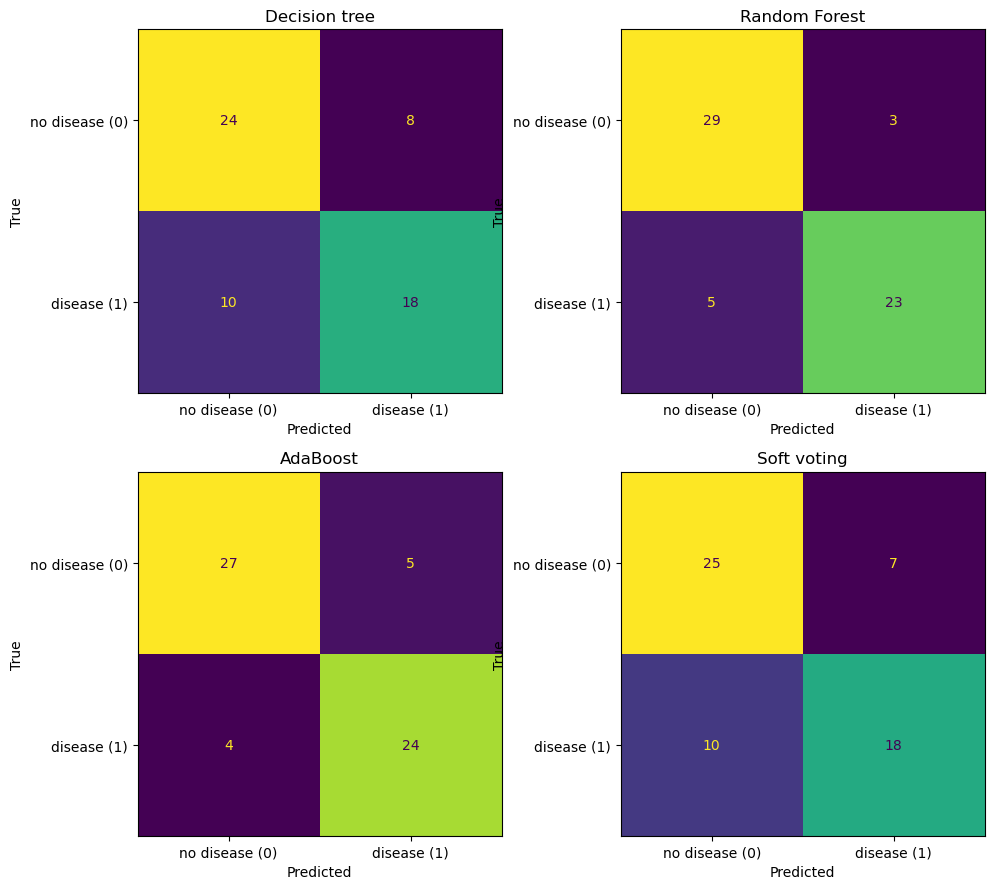

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, precision_score, recall_score

rows = []
for name, preds in [
    ("Decision tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("AdaBoost", y_pred_ada),
    ("Soft voting", y_pred_vote),
]:
    rows.append({
        "model": name,
        "precision_w": precision_score(y_test, preds, average="weighted"),
        "recall_w": recall_score(y_test, preds, average="weighted"),
        "f1_w": f1_score(y_test, preds, average="weighted"),
    })

metrics_df = pd.DataFrame(rows).set_index("model").round(4)
metrics_df.columns = ["Precision (weighted)", "Recall (weighted)", "F1 (weighted)"]
print("Test-set summary (weighted averages over both classes):")
display(metrics_df)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
labels_txt = ["no disease (0)", "disease (1)"]
for ax, (title, preds) in zip(
    axes.ravel(),
    [
        ("Decision tree", y_pred_dt),
        ("Random Forest", y_pred_rf),
        ("AdaBoost", y_pred_ada),
        ("Soft voting", y_pred_vote),
    ],
):
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=labels_txt).plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

### 3.5 Task 7 — Random Forest feature importances


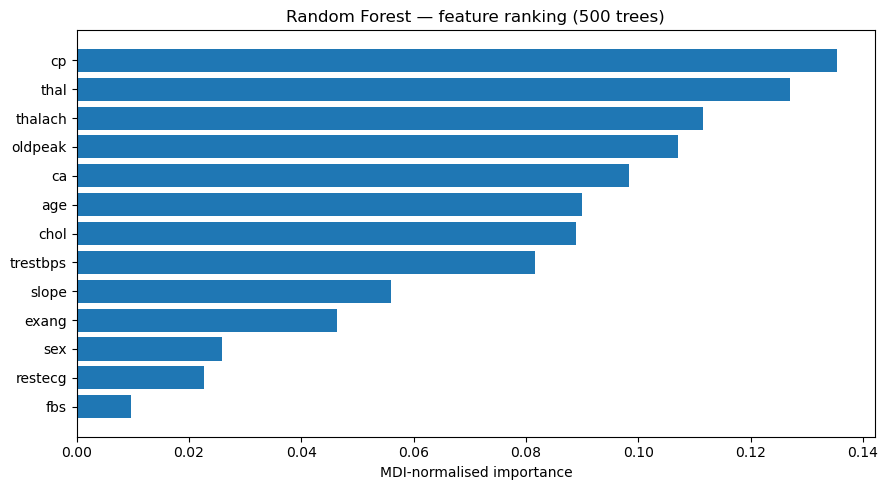

,feature,importance
0,cp,0.135374
1,thal,0.126934
2,thalach,0.111444
3,oldpeak,0.107104
4,ca,0.098265
5,age,0.090023
6,chol,0.088961
7,trestbps,0.081556
8,slope,0.055893
9,exang,0.046265


In [7]:
fi = (
    pd.DataFrame({"feature": feature_cols, "importance": rf_clf.feature_importances_})
    .sort_values("importance")  # low→high so tallest bar equals strongest predictor after barh stacking
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi["feature"], fi["importance"], color="#1f77b4")
ax.set_xlabel("MDI-normalised importance")
ax.set_title("Random Forest — feature ranking (500 trees)")
plt.tight_layout()
plt.show()

display(fi.iloc[::-1].reset_index(drop=True))

**Interpretive note.** Highest bars usually involve **`cp`, `thal`, `thalach`, `oldpeak`, `ca`** — angina phenotype, perfusion cues, attainable heart-rate response, exercise ST shift, and angiographically inferred vessel burden. Matches domain intuition, although **MDI** can overweight high-cardinality or continuous inputs.

### 3.6 Task 8 — Discussion


##### (a) Relative performance and expectations

The **Random Forest** attains the strongest **weighted precision / recall / F1** on this hold-out fold, with **AdaBoost** a close second. The **unpruned decision tree** is markedly weaker—axis-aligned rules on ~240 training patients oscillate with sampling noise. Those gaps match the usual story that **variance reduction** and **adaptive re-weighting**  outperform a **single high-capacity tree**.

**Soft voting**  **does not beat** the Random Forest here. Merging class probabilities with **equal weights** hands the same influence to a baseline tree whose **probability estimates can be sharp but miscalibrated**. Averaging pulls the ensemble toward that extremity, so **fusion is not monotone** in individual accuracies. 

##### (b) Bagging versus boosting on the Cleveland features

**Bagging (RF)** trains many **deep, low-bias** trees on bootstrap bags and random feature subsets, then aggregates votes or probabilities. That recipe specifically **dampens variance** from unstable recursive splits.

**Boosting (AdaBoost)** fits **shallow** weak learners in sequence, up-weighting currently misclassified rows. It often attacks **structured bias** progressively; with enough stages it can rival bagging on moderately sized tabular data.

On this notebook’s run, RF leads by a **small margin**. Plausible reasons include (i) decorrelated deep trees capture **threshold interactions** between mixed continuous/ordinal measurements, and (ii) boosting’s default shallow stumps may **underfit subtle curvatures** unless depth or learning rate is tuned.

##### (c) Ensemble trade-offs versus the decision tree baseline

**Advantages:** Improved **out-of-sample calibration of error** (fewer severe confusions in the matrices), less sensitivity to the particular 80% training draw, and—for Random Forest—diagnostics such as **MDI importances** even though they are imperfect.

**Disadvantages:** Orders-of-magnitude higher **fit latency and memory** (`n_estimators=500` twice plus voting), harder **auditability** for clinicians, and—as shown—**combiners can underperform** elite single models when members disagree badly in probability space.
